In [16]:
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [17]:
# ── 資料載入 ──

def get_subject_id(filename):
    return filename.split('_ses-')[0]

def scan_session_folder(folder_path):
    result = {}
    for fname in sorted(os.listdir(folder_path)):
        if fname.endswith('.mat'):
            result[get_subject_id(fname)] = os.path.join(folder_path, fname)
    return result

def load_band_energy(filepath):
    with h5py.File(filepath, 'r') as f:
        data = np.array(f['band_energy']).T  # (5,39,32) → (32,39,5)
    return data

def load_group(ss01_map, ss02_map, ss03_map, complete_subs):
    X1, X2, X3 = [], [], []
    for sub_id in complete_subs:
        X1.append(load_band_energy(ss01_map[sub_id]))
        X2.append(load_band_energy(ss02_map[sub_id]))
        X3.append(load_band_energy(ss03_map[sub_id]))
    return np.array(X1), np.array(X2), np.array(X3)

BASE_AMATEUR = r'D:\Tseng\圍棋\amateur\band_energy_batch_outputs_2026'
BASE_MASTER  = r'D:\Tseng\圍棋\master\band_energy_batch_outputs_2026'
BASE_PROF    = r'D:\Tseng\圍棋\prof\band_energy_batch_outputs_2026'

PATHS = {
    'amateur': {s: os.path.join(BASE_AMATEUR, s) for s in ['ss01','ss02','ss03']},
    'master':  {s: os.path.join(BASE_MASTER,  s) for s in ['ss01','ss02','ss03']},
    'prof':    {s: os.path.join(BASE_PROF,    s) for s in ['ss01','ss02','ss03']},
}

maps = {}
complete = {}
for group in ['amateur', 'master', 'prof']:
    m1 = scan_session_folder(PATHS[group]['ss01'])
    m2 = scan_session_folder(PATHS[group]['ss02'])
    m3 = scan_session_folder(PATHS[group]['ss03'])
    maps[group] = (m1, m2, m3)
    complete[group] = sorted(set(m1) & set(m2) & set(m3))
    print(f"[{group}] 完整 subject：{len(complete[group])} 人")

print("\n載入資料...")
X_a1, X_a2, X_a3 = load_group(*maps['amateur'], complete['amateur'])
X_m1, X_m2, X_m3 = load_group(*maps['master'],  complete['master'])
X_p1, X_p2, X_p3 = load_group(*maps['prof'],    complete['prof'])
print("完成")

[amateur] 完整 subject：28 人
[master] 完整 subject：20 人
[prof] 完整 subject：8 人

載入資料...
完成


In [18]:
# ── 各 session 分開分類 ──
# LOSO (Leave-One-Subject-Out)：每個 subject 輪流當 test set

CLASS_NAMES = ['amateur', 'master', 'prof']

def extract_features(X):
    """(n, 32ch, 39time, 5bands) → (n, 160)"""
    X = np.log(X + 1e-8)
    X = X[:, :, 1:-1, :]    # 去第一個 & 最後一個（NaN）
    X = X.mean(axis=2)       # mean over time → (n, 32, 5)
    return X.reshape(len(X), -1)

def make_pipeline(n_train, n_features, n_pca=40):
    # PCA 的 n_components 不能超過 min(n_samples, n_features)
    n_components = min(n_pca, n_train, n_features) - 1
    return Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=n_components)),
        ('clf',    SVC(kernel='rbf', C=10, gamma='scale',
                       class_weight='balanced', random_state=42)),
    ])

# 三個 session 的資料
sessions = {
    'ss01': (X_a1, X_m1, X_p1),
    'ss02': (X_a2, X_m2, X_p2),
    'ss03': (X_a3, X_m3, X_p3),
}

session_results = {}

for ss_name, (Xa, Xm, Xp) in sessions.items():
    n_a, n_m, n_p = len(Xa), len(Xm), len(Xp)
    n_total = n_a + n_m + n_p

    # 提取特徵
    Fa = extract_features(Xa)
    Fm = extract_features(Xm)
    Fp = extract_features(Xp)

    # 合併所有 subjects
    X_ss = np.vstack([Fa, Fm, Fp])
    y_ss = np.concatenate([
        np.zeros(n_a),
        np.ones(n_m),
        np.full(n_p, 2)
    ]).astype(int)

    all_preds, all_true = [], []

    # LOSO：每個 subject 輪流當 test
    for test_subject_idx in range(n_total):
        test_mask  = np.arange(n_total) == test_subject_idx
        train_mask = ~test_mask
        
        X_tr, y_tr = X_ss[train_mask], y_ss[train_mask]
        X_te, y_te = X_ss[test_mask],  y_ss[test_mask]

        pipe = make_pipeline(n_train=len(X_tr), n_features=X_tr.shape[1])
        pipe.fit(X_tr, y_tr)
        pred = pipe.predict(X_te)[0]

        all_preds.append(pred)
        all_true.append(y_te[0])

    all_preds = np.array(all_preds)
    all_true = np.array(all_true)
    
    acc = accuracy_score(all_true, all_preds)
    f1 = f1_score(all_true, all_preds, average='macro', zero_division=0)
    
    session_results[ss_name] = {
        'acc': acc, 'f1': f1,
        'preds': all_preds, 'true': all_true
    }
    print(f"[{ss_name}]  Acc={acc:.3f}  F1={f1:.3f}  "
          f"(amateur={n_a}, master={n_m}, prof={n_p}, total={n_total})")
    print(classification_report(all_true, all_preds, target_names=CLASS_NAMES, zero_division=0))

[ss01]  Acc=0.375  F1=0.313  (amateur=28, master=20, prof=8, total=56)
              precision    recall  f1-score   support

     amateur       0.46      0.46      0.46        28
      master       0.33      0.35      0.34        20
        prof       0.14      0.12      0.13         8

    accuracy                           0.38        56
   macro avg       0.31      0.31      0.31        56
weighted avg       0.37      0.38      0.37        56

[ss02]  Acc=0.393  F1=0.380  (amateur=28, master=20, prof=8, total=56)
              precision    recall  f1-score   support

     amateur       0.48      0.46      0.47        28
      master       0.29      0.30      0.29        20
        prof       0.38      0.38      0.38         8

    accuracy                           0.39        56
   macro avg       0.38      0.38      0.38        56
weighted avg       0.40      0.39      0.39        56

[ss03]  Acc=0.464  F1=0.372  (amateur=28, master=20, prof=8, total=56)
              precision  

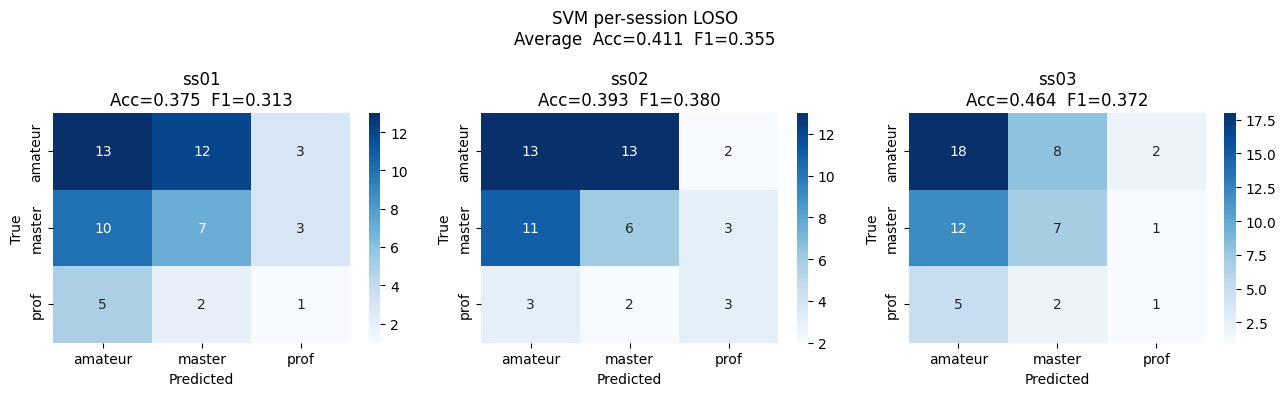

>>> 三 session 平均  Acc=0.411  F1=0.355


In [22]:
# ── 三個 session 的混淆矩陣 ──

all_ss_acc_160 = np.mean([r['acc'] for r in session_results.values()])
all_ss_f1_160  = np.mean([r['f1']  for r in session_results.values()])

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (ss_name, res) in zip(axes, session_results.items()):
    cm = confusion_matrix(res['true'], res['preds'], labels=[0, 1, 2])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{ss_name}\nAcc={res["acc"]:.3f}  F1={res["f1"]:.3f}')

fig.suptitle(f'SVM per-session LOSO\n'
             f'Average  Acc={all_ss_acc_160:.3f}  F1={all_ss_f1_160:.3f}', fontsize=12)
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\SVM\svm_per_session_result.png', dpi=150, bbox_inches='tight')
plt.show()

print(f">>> 三 session 平均  Acc={all_ss_acc_160:.3f}  F1={all_ss_f1_160:.3f}")

=== top10ch × all bands (per-session LOSO) ===

[ss01]  Acc=0.393  F1=0.338
              precision    recall  f1-score   support

     amateur       0.54      0.54      0.54        28
      master       0.31      0.25      0.28        20
        prof       0.17      0.25      0.20         8

    accuracy                           0.39        56
   macro avg       0.34      0.35      0.34        56
weighted avg       0.40      0.39      0.40        56

[ss02]  Acc=0.500  F1=0.448
              precision    recall  f1-score   support

     amateur       0.59      0.57      0.58        28
      master       0.42      0.50      0.45        20
        prof       0.40      0.25      0.31         8

    accuracy                           0.50        56
   macro avg       0.47      0.44      0.45        56
weighted avg       0.50      0.50      0.50        56

[ss03]  Acc=0.518  F1=0.441
              precision    recall  f1-score   support

     amateur       0.63      0.68      0.66        

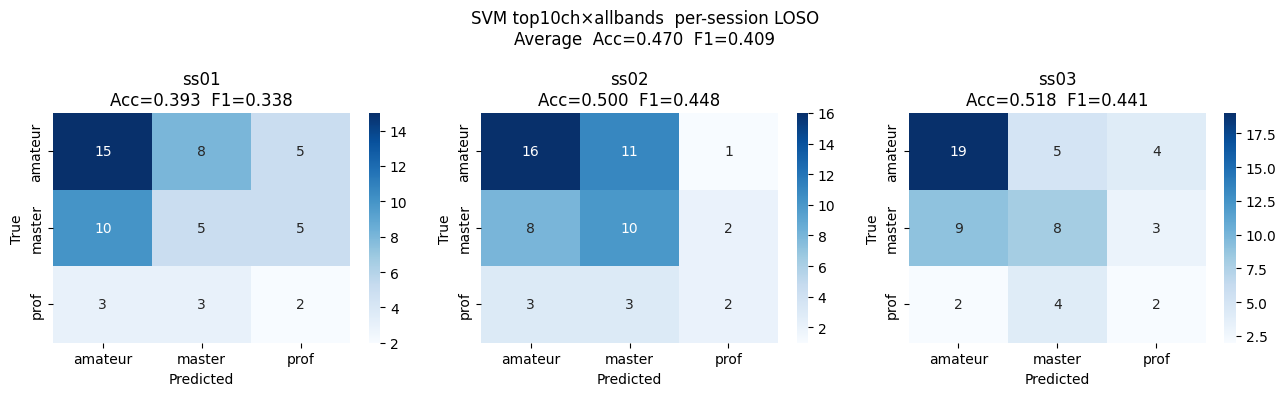


=== 比較：all_160 vs top10ch ===
Session   all_160 Acc   top10 Acc  all_160 F1    top10 F1
ss01           0.375       0.393       0.313       0.338
ss02           0.393       0.500       0.380       0.448
ss03           0.464       0.518       0.372       0.441


In [20]:
# ── top10ch × all bands：per-session LOSO 分類 ──

TOP_CHS = [0, 6, 7, 10, 13, 14, 21, 22, 28, 31]

def extract_selected(X_raw, channels=TOP_CHS, bands=[0,1,2,3,4]):
    """(n, 32ch, 39time, 5bands) → (n, len(channels)*len(bands))"""
    X = np.log(X_raw + 1e-8)
    X = X[:, :, 1:-1, :]
    X = X.mean(axis=2)
    X = X[:, channels, :]
    X = X[:, :, bands]
    return X.reshape(len(X), -1)

session_results_top10 = {}

print('=== top10ch × all bands (per-session LOSO) ===\n')

for ss_name, (Xa, Xm, Xp) in sessions.items():
    n_a, n_m, n_p = len(Xa), len(Xm), len(Xp)
    n_total = n_a + n_m + n_p

    # 提取特徵
    Fa = extract_selected(Xa)
    Fm = extract_selected(Xm)
    Fp = extract_selected(Xp)

    # 合併所有 subjects
    X_ss = np.vstack([Fa, Fm, Fp])
    y_ss = np.concatenate([np.zeros(n_a), np.ones(n_m), np.full(n_p, 2)]).astype(int)

    dim = X_ss.shape[1]
    all_preds, all_true = [], []

    # LOSO：每個 subject 輪流當 test
    for test_subject_idx in range(n_total):
        test_mask  = np.arange(n_total) == test_subject_idx
        train_mask = ~test_mask
        
        X_tr, y_tr = X_ss[train_mask], y_ss[train_mask]
        X_te, y_te = X_ss[test_mask],  y_ss[test_mask]

        n_pca = min(20, dim, len(X_tr)) - 1
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('pca',    PCA(n_components=n_pca)),
            ('clf',    SVC(kernel='rbf', C=10, gamma='scale',
                           class_weight='balanced', random_state=42)),
        ])
        pipe.fit(X_tr, y_tr)
        pred = pipe.predict(X_te)[0]

        all_preds.append(pred)
        all_true.append(y_te[0])

    all_preds = np.array(all_preds)
    all_true = np.array(all_true)
    
    acc = accuracy_score(all_true, all_preds)
    f1 = f1_score(all_true, all_preds, average='macro', zero_division=0)
    
    session_results_top10[ss_name] = {
        'acc': acc, 'f1': f1,
        'preds': all_preds, 'true': all_true
    }
    print(f"[{ss_name}]  Acc={acc:.3f}  F1={f1:.3f}")
    print(classification_report(all_true, all_preds, target_names=CLASS_NAMES, zero_division=0))

# 三個 session 的平均
all_ss_acc = np.mean([r['acc'] for r in session_results_top10.values()])
all_ss_f1  = np.mean([r['f1']  for r in session_results_top10.values()])
print(f">>> 三 session 平均  Acc={all_ss_acc:.3f}  F1={all_ss_f1:.3f}")

# 混淆矩陣
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (ss_name, res) in zip(axes, session_results_top10.items()):
    cm = confusion_matrix(res['true'], res['preds'], labels=[0, 1, 2])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{ss_name}\nAcc={res["acc"]:.3f}  F1={res["f1"]:.3f}')
fig.suptitle(f'SVM top10ch×allbands  per-session LOSO\n'
             f'Average  Acc={all_ss_acc:.3f}  F1={all_ss_f1:.3f}', fontsize=12)
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\SVM\svm_per_session_top10ch_loso.png', dpi=150, bbox_inches='tight')
plt.show()

# 比較
print('\n=== 比較：all_160 vs top10ch ===')
print(f"{'Session':<8s}  {'all_160 Acc':>10s}  {'top10 Acc':>10s}  {'all_160 F1':>10s}  {'top10 F1':>10s}")
for ss_name in sessions:
    r1 = session_results[ss_name]
    r2 = session_results_top10[ss_name]
    print(f"{ss_name:<8s}  {r1['acc']:10.3f}  {r2['acc']:10.3f}  {r1['f1']:10.3f}  {r2['f1']:10.3f}")